In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\origami\AppData\Local\Temp\ipykernel_70296\1707547792.py:2: DtypeWarning: Columns (0: ONS_code, 1: ONS_geo, 2: Geo_level, 3: Country, 4: Region) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('12region.csv')


[2025.0年数据] 头部地区: ['South East', 'London']
[2025.0年数据] 底部地区: ['Northern Ireland', 'Wales']


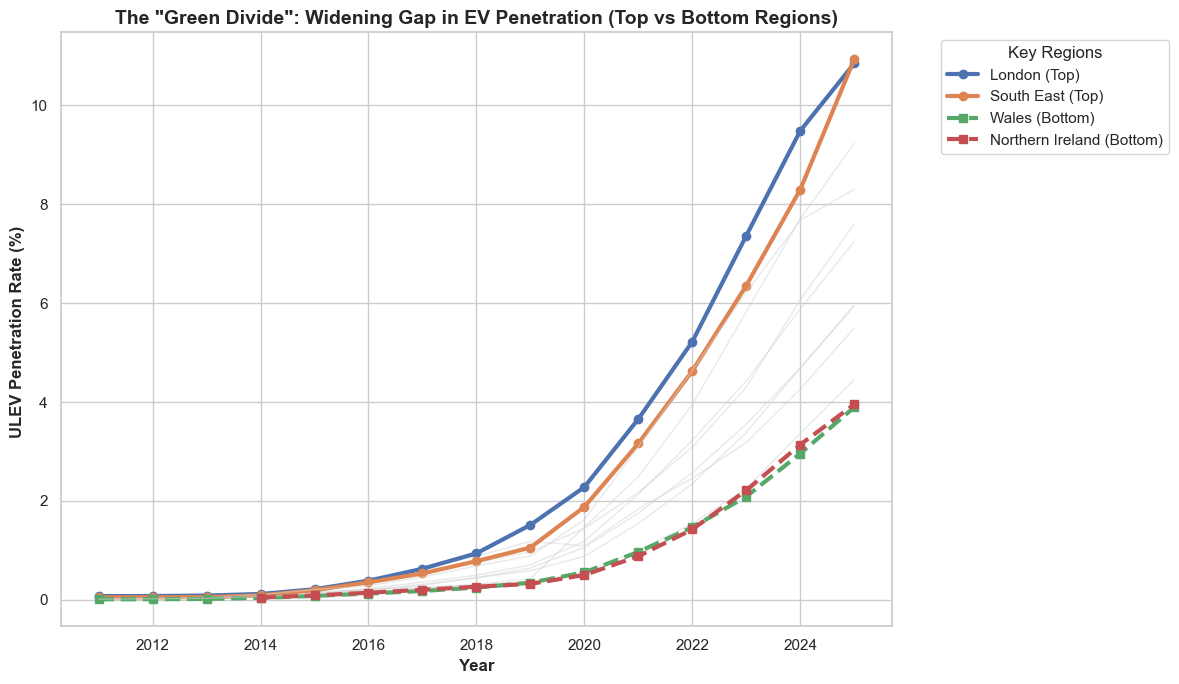


--- 鸿沟变化数据已导出至 green_divide_gap_summary.csv ---
ONS_geo    year  Top_Avg  Bottom_Avg  Green_Gap (Percentage Points)
10       2021.0     3.41        0.93                           2.48
11       2022.0     4.93        1.45                           3.48
12       2023.0     6.86        2.15                           4.71
13       2024.0     8.89        3.05                           5.84
14       2025.0    10.89        3.92                           6.97


In [2]:

# 1. 加载与数据清洗
df = pd.read_csv('12region.csv')

# 确保核心列是数值格式
df['veh_ulev_total'] = pd.to_numeric(df['veh_ulev_total'], errors='coerce')
df['veh_total'] = pd.to_numeric(df['veh_total'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# 计算低排放车渗透率 (%)
df['penetration_pct'] = (df['veh_ulev_total'] / df['veh_total']) * 100

# 过滤掉没有有效数据的年份
df_valid = df.dropna(subset=['year', 'penetration_pct']).copy()

# 2. 动态识别“头部”与“底部”地区
# 找到数据中最新的一年 (例如 2025)
latest_year = df_valid['year'].max()

# 按照最新一年的渗透率对地区进行降序排列
df_latest = df_valid[df_valid['year'] == latest_year].sort_values(by='penetration_pct', ascending=False)

# 提取排名前2和后2的地区名单
top_regions = df_latest['ONS_geo'].head(2).tolist()
bottom_regions = df_latest['ONS_geo'].tail(2).tolist()

print(f"[{latest_year}年数据] 头部地区: {top_regions}")
print(f"[{latest_year}年数据] 底部地区: {bottom_regions}")

# 3. 绘制“绿色鸿沟”折线图
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 循环绘制 12 个地区的折线
for region in df_valid['ONS_geo'].unique():
    region_data = df_valid[df_valid['ONS_geo'] == region]
    
    # 头部地区：粗实线，显眼标记
    if region in top_regions:
        plt.plot(region_data['year'], region_data['penetration_pct'], 
                 marker='o', linewidth=3, label=f"{region} (Top)")
    
    # 底部地区：粗虚线，显眼标记
    elif region in bottom_regions:
        plt.plot(region_data['year'], region_data['penetration_pct'], 
                 marker='s', linewidth=3, linestyle='--', label=f"{region} (Bottom)")
                 
    # 中游地区：浅灰色细线，作为背景衬托
    else:
        plt.plot(region_data['year'], region_data['penetration_pct'], 
                 color='lightgray', linewidth=1, alpha=0.5)

# 设置图表标题与标签
plt.title('The "Green Divide": Widening Gap in EV Penetration (Top vs Bottom Regions)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('ULEV Penetration Rate (%) ', fontsize=12, fontweight='bold')

# 将图例放在图表外部
plt.legend(title='Key Regions', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 4. 计算绝对差距 (Gap) 并导出数据
# 使用数据透视表把地区变成列
pivot_df = df_valid.pivot_table(index='year', columns='ONS_geo', values='penetration_pct')

# 计算每年 前两名平均值 和 后两名平均值
pivot_df['Top_Avg'] = pivot_df[top_regions].mean(axis=1)
pivot_df['Bottom_Avg'] = pivot_df[bottom_regions].mean(axis=1)

# 计算绝对差值 (绿色鸿沟的具体百分点)
pivot_df['Green_Gap (Percentage Points)'] = pivot_df['Top_Avg'] - pivot_df['Bottom_Avg']

# 整理数据并导出供报告使用
gap_summary = pivot_df[['Top_Avg', 'Bottom_Avg', 'Green_Gap (Percentage Points)']].round(2).reset_index()

print("\n--- 鸿沟变化数据已导出至 green_divide_gap_summary.csv ---")
print(gap_summary.tail(5)) # 打印最近5年的数据看看差距拉大的趋势